In [29]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns



In [7]:
np.random.seed(7)

n = 800


df = pd.DataFrame({
    "age": np.random.randint(20, 80, n),
    "bmi": np.random.normal(26,5,n),
    "blood_pressure": np.random.normal(120, 18, n),
    "glucose": np.random.normal(95, 20, n),
    "smoking_status": np.random.choice(["never", "former", "current"], n),
    "income_bracket": np.random.choice(["low", "medium", "high"], n),
    "hospital_visits": np.random.poisson(1.5, n),
    "has_condition": np.random.binomial(1, 0.25, n)
})


mask_mcar = np.random.rand(n) < 0.12
df.loc[mask_mcar, "bmi"] = np.nan

mask_mar = df['income_bracket'] == "low"
df.loc[mask_mar & (np.random.rand(n) < 0.35), "glucose"] = np.nan


mask_mnar = df["blood_pressure"] > 145
df.loc[mask_mnar * (np.random.rand(n) < 0.4), "blood_pressure"] = np.nan


df.to_csv("day02_health.csv", index=False)

print(df.shape)

(800, 8)


In [5]:
df.shape

(800, 8)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              800 non-null    int32  
 1   bmi              721 non-null    float64
 2   blood_pressure   772 non-null    float64
 3   glucose          707 non-null    float64
 4   smoking_status   800 non-null    str    
 5   income_bracket   800 non-null    str    
 6   hospital_visits  800 non-null    int32  
 7   has_condition    800 non-null    int32  
dtypes: float64(3), int32(3), str(2)
memory usage: 40.8 KB


In [11]:
df.isnull().sum()

age                 0
bmi                79
blood_pressure     28
glucose            93
smoking_status      0
income_bracket      0
hospital_visits     0
has_condition       0
dtype: int64

In [14]:
missing_pct = (df.isnull().sum() / len(df)) * 100
display(missing_pct.round(2))

age                 0.00
bmi                 9.88
blood_pressure      3.50
glucose            11.62
smoking_status      0.00
income_bracket      0.00
hospital_visits     0.00
has_condition       0.00
dtype: float64

In [20]:

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,800.0,NaN,NaN,NaN,49.99,17.335456,20.0,35.0,50.0,65.0,79.0
bmi,721.0,NaN,NaN,NaN,25.896078,4.849974,11.763933,22.676523,25.985495,29.136199,42.417575
blood_pressure,772.0,NaN,NaN,NaN,117.81094,16.925701,63.175101,106.132123,117.793968,129.094955,173.437292
glucose,707.0,NaN,NaN,NaN,95.1582,20.374134,18.13697,81.424708,95.144198,109.520389,149.661282
smoking_status,800,3,current,286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income_bracket,800,3,low,282,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hospital_visits,800.0,NaN,NaN,NaN,1.49,1.183914,0.0,1.0,1.0,2.0,6.0
has_condition,800.0,NaN,NaN,NaN,0.23125,0.421896,0.0,0.0,0.0,0.0,1.0


In [21]:
df['smoking_status'].value_counts(normalize=True)

smoking_status
current    0.3575
never      0.3350
former     0.3075
Name: proportion, dtype: float64

In [22]:
df['income_bracket'].value_counts(normalize=True)

income_bracket
low       0.3525
high      0.3275
medium    0.3200
Name: proportion, dtype: float64

In [24]:
df['has_condition'].value_counts(normalize=True).round(2)

has_condition
0    0.77
1    0.23
Name: proportion, dtype: float64

C:\Users\pined\AppData\Local\Temp\ipykernel_9520\712101438.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_counts.index, y=total_counts.values, ax=axes[i], palette=colors[i])
C:\Users\pined\AppData\Local\Temp\ipykernel_9520\712101438.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_counts.index, y=total_counts.values, ax=axes[i], palette=colors[i])
C:\Users\pined\AppData\Local\Temp\ipykernel_9520\712101438.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_counts.index, y=total_counts.values, ax=axes[i], pa

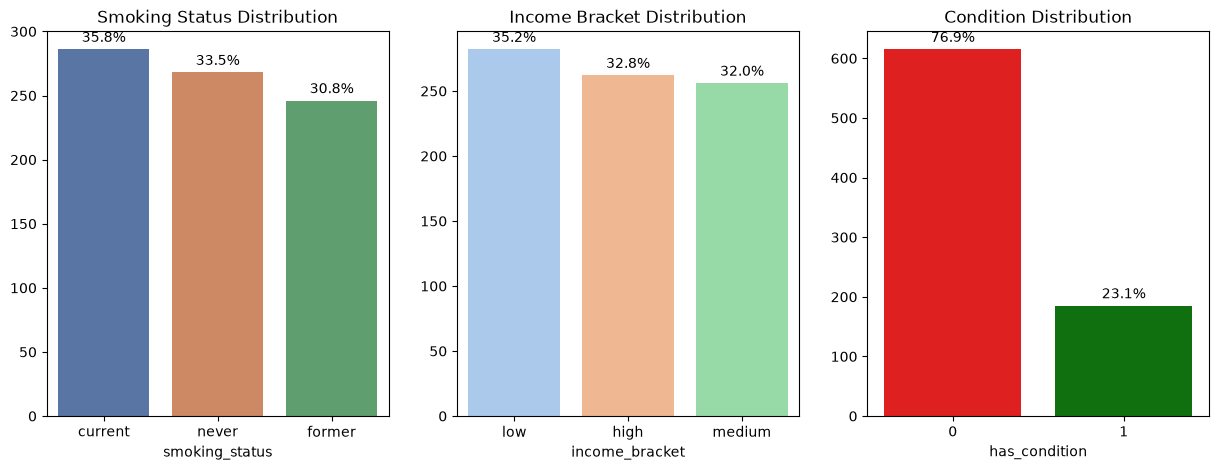

In [ ]:
cat_cols = ['smoking_status', 'income_bracket', 'has_condition']
colors = ['deep', 'pastel', ['red', 'green']]
titles = ['Smoking Status Distribution', 'Income Bracket Distribution', 'Condition Distribution']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))


for i, col in enumerate(cat_cols):
    total_counts = df[col].value_counts()
    total = len(df[col].dropna())
    
    sns.barplot(x=total_counts.index, y=total_counts.values, ax=axes[i], palette=colors[i])
    
    axes[i].set_title(titles[i])
    
    for container in axes[i].containers:
        labels = [f'{(v.get_height() / total * 100):.1f}%' for v in container]
        axes[i].bar_label(container, labels=labels, padding=3)
plt.tight_layout()
plt.savefig("categorical_distributions.png")

# # smoking_status
# sns.barplot(x=df['smoking_status'].value_counts().index, y=df['smoking_status'].value_counts().values, ax=axes[0], palette='deep')
# plt.title('Smoking Status Distribution')


# # Income Bracket
# sns.barplot(x=df['income_bracket'].value_counts().index, y=df['income_bracket'].value_counts().values, ax=axes[1], palette='pastel')
# plt.title('Income Bracket Distribution')

# # Condition
# sns.barplot(x=df['has_condition'].value_counts().index, y=df['has_condition'].value_counts().values, ax=axes[2], palette=['red', 'green'])
# plt.title('Condition Distribution')

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              800 non-null    int32  
 1   bmi              721 non-null    float64
 2   blood_pressure   772 non-null    float64
 3   glucose          707 non-null    float64
 4   smoking_status   800 non-null    str    
 5   income_bracket   800 non-null    str    
 6   hospital_visits  800 non-null    int32  
 7   has_condition    800 non-null    int32  
dtypes: float64(3), int32(3), str(2)
memory usage: 40.8 KB
